# Análisis Exploratorio de Datos — ChicharritAI

Exploración del dataset de monitoreo de *Dalbulus maidis* (chicharrita del maíz) en Argentina.

**Datos**: 2 temporadas (2024-2025 y 2025-2026), ~830 filas (localidad × temporada), 28 features climáticas y geográficas + target binario (outbreak ≥5 adultos/trampa).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
TARGET_COLORS = {0: "#2ecc71", 1: "#e74c3c"}
TARGET_LABELS = {0: "Safe (<5)", 1: "Outbreak (≥5)"}
REGION_ORDER = ["NOA", "NEA", "CENTRO NORTE", "LITORAL", "CENTRO SUR", "URUGUAY"]

df = pd.read_csv("output/dataset.csv")
print(f"Dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Temporadas: {df['temporada'].value_counts().to_dict()}")
print(f"Target: {df['target'].value_counts().to_dict()}")

meta_cols = ["localidad", "provincia", "region", "temporada",
             "max_capturas", "mean_capturas", "n_lecturas", "n_detecciones", "target"]
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f"Features: {len(feature_cols)}")

Dataset: 831 filas × 37 columnas
Temporadas: {'2024-2025': 509, '2025-2026': 322}
Target: {1: 510, 0: 321}
Features: 28


## 1. Datos de trampas

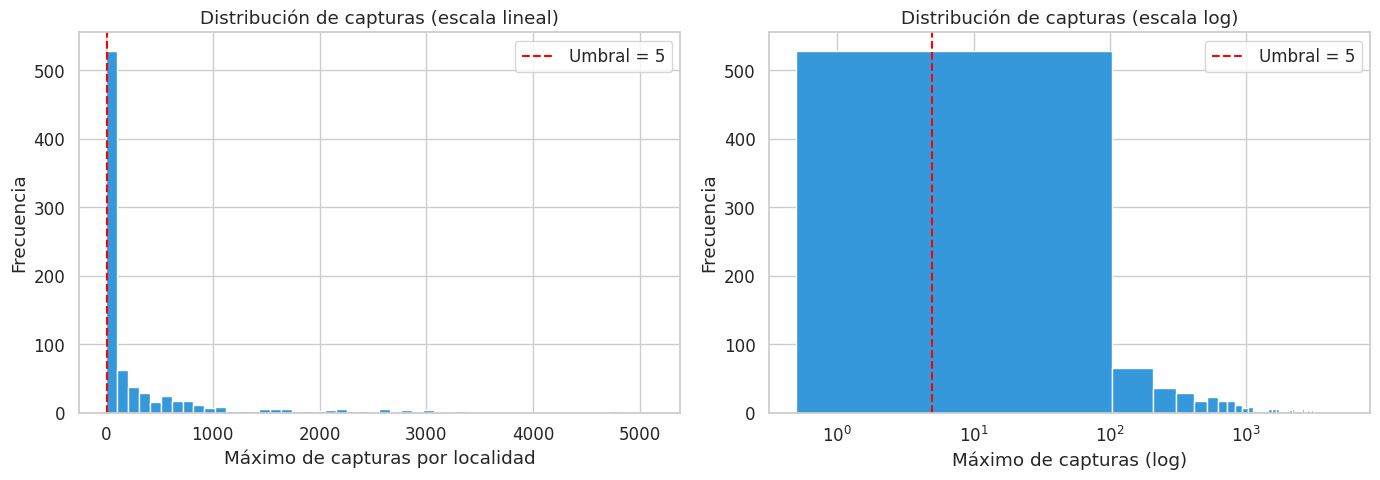

In [15]:
# 1.1 Distribución de capturas máximas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala lineal
axes[0].hist(df["max_capturas"].dropna(), bins=50, color="#3498db", edgecolor="white")
axes[0].axvline(x=5, color="red", linestyle="--", label="Umbral = 5")
axes[0].set_xlabel("Máximo de capturas por localidad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de capturas (escala lineal)")
axes[0].legend()

# Escala log
axes[1].hist(df["max_capturas"].dropna().clip(lower=0.5), bins=50, color="#3498db", edgecolor="white")
axes[1].axvline(x=5, color="red", linestyle="--", label="Umbral = 5")
axes[1].set_xscale("log")
axes[1].set_xlabel("Máximo de capturas (log)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de capturas (escala log)")
axes[1].legend()

plt.tight_layout()
plt.show()

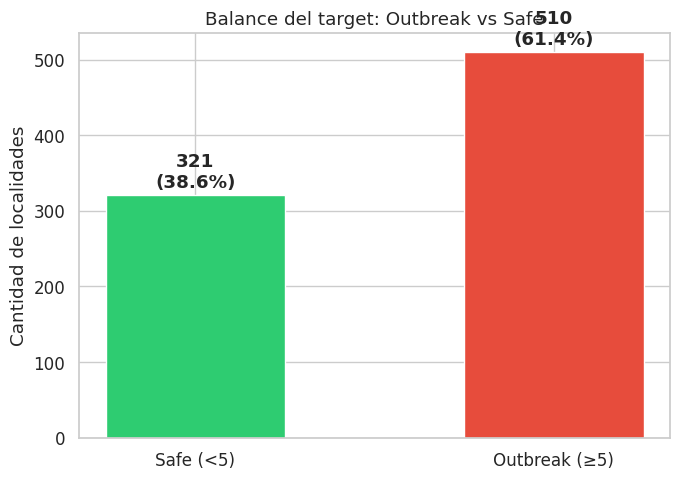

In [16]:
# 1.2 Balance del target
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["target"].value_counts().sort_index()
bars = ax.bar(
    [TARGET_LABELS[i] for i in counts.index],
    counts.values,
    color=[TARGET_COLORS[i] for i in counts.index],
    edgecolor="white",
    width=0.5,
)
for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Cantidad de localidades")
ax.set_title("Balance del target: Outbreak vs Safe")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2571021/1650818487.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y="max_capturas", order=order, palette="Set2", ax=ax)


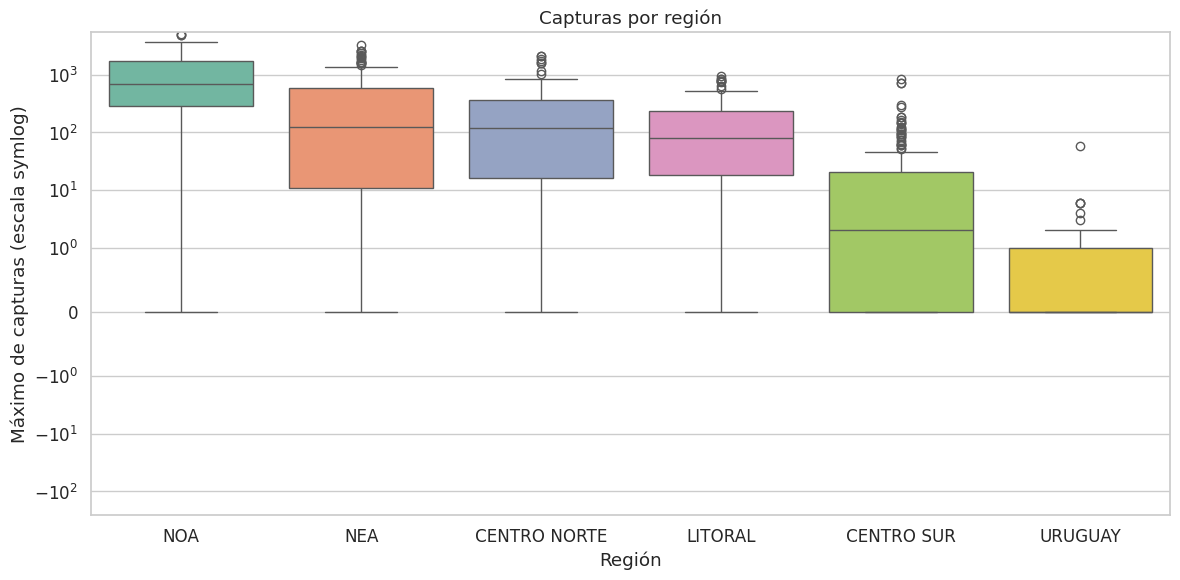

In [17]:
# 1.3 Capturas por región (boxplot, escala log)
fig, ax = plt.subplots(figsize=(12, 6))
order = (df.groupby("region")["max_capturas"].median()
         .reindex(REGION_ORDER).sort_values(ascending=False).index)
sns.boxplot(data=df, x="region", y="max_capturas", order=order, palette="Set2", ax=ax)
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel("Región")
ax.set_ylabel("Máximo de capturas (escala symlog)")
ax.set_title("Capturas por región")
plt.tight_layout()
plt.show()

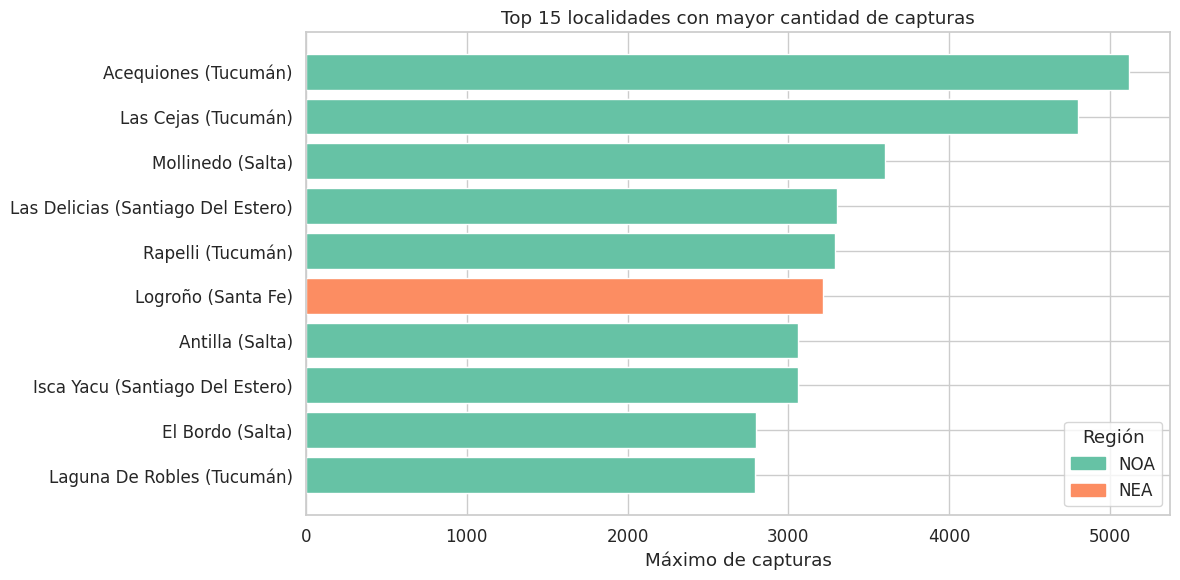

In [18]:
# 1.4 Top 15 localidades con más capturas
top15 = df.nlargest(15, "max_capturas")[["localidad", "provincia", "region", "max_capturas"]].copy()
top15["label"] = top15["localidad"].str.title() + " (" + top15["provincia"].fillna("") + ")"

fig, ax = plt.subplots(figsize=(12, 6))
colors = [sns.color_palette("Set2")[REGION_ORDER.index(r)] if r in REGION_ORDER else "gray"
          for r in top15["region"]]
bars = ax.barh(top15["label"][::-1], top15["max_capturas"][::-1], color=colors[::-1], edgecolor="white")
ax.set_xlabel("Máximo de capturas")
ax.set_title("Top 15 localidades con mayor cantidad de capturas")

# Leyenda de regiones
from matplotlib.patches import Patch
handles = [Patch(color=sns.color_palette("Set2")[i], label=r)
           for i, r in enumerate(REGION_ORDER) if r in top15["region"].values]
ax.legend(handles=handles, title="Región", loc="lower right")
plt.tight_layout()
plt.show()

## 2. Distribución geográfica

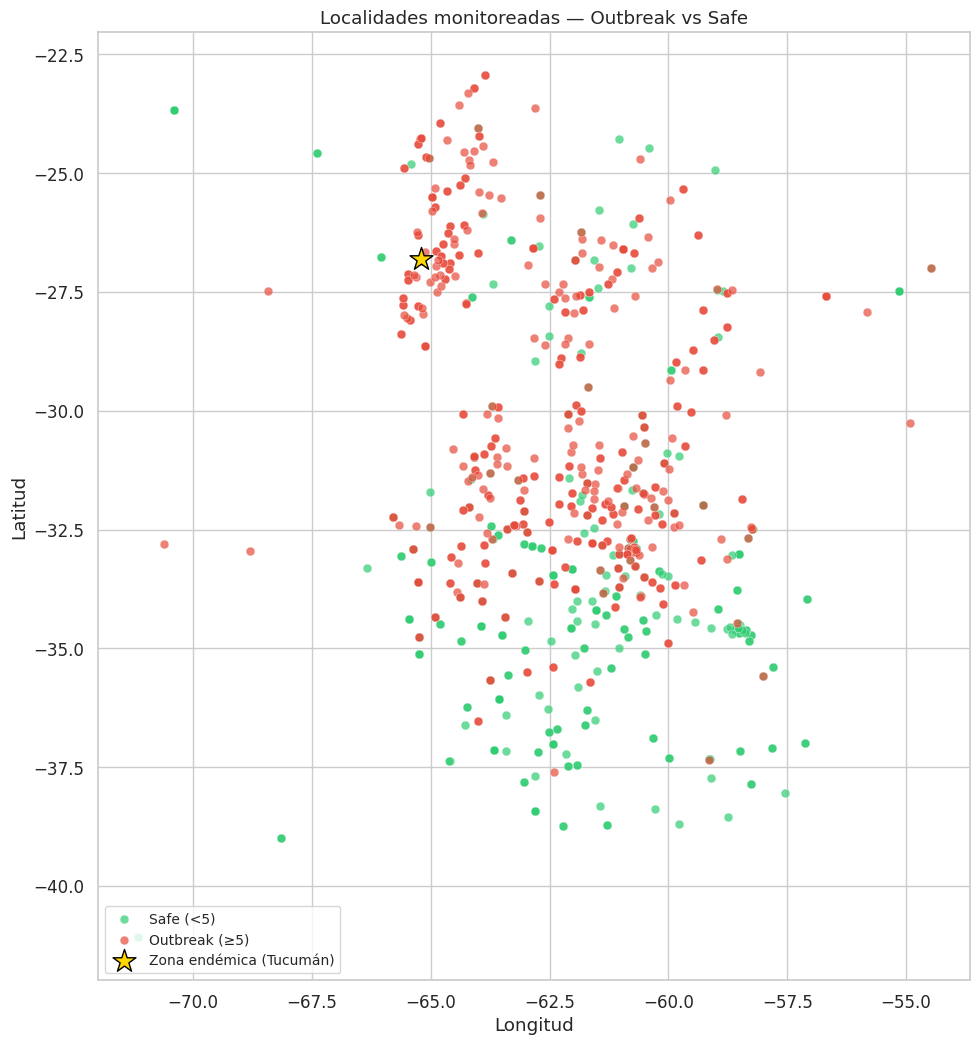

Nota: 6 localidades fuera de rango geográfico (Uruguay, outliers)


In [19]:
# 2.1 Mapa de localidades coloreadas por target
# Filtrar a rango geográfico razonable de Argentina
df_geo = df[(df["lat"] > -45) & (df["lat"] < -20) & (df["lon"] > -75) & (df["lon"] < -53)]

fig, ax = plt.subplots(figsize=(10, 12))

# Puntos: safe primero (fondo), outbreak encima
for target_val in [0, 1]:
    mask = df_geo["target"] == target_val
    ax.scatter(
        df_geo.loc[mask, "lon"], df_geo.loc[mask, "lat"],
        c=TARGET_COLORS[target_val], label=TARGET_LABELS[target_val],
        s=40, alpha=0.7, edgecolors="white", linewidth=0.3,
    )

# Zona endémica (Tucumán)
ax.scatter(-65.2, -26.8, c="gold", marker="*", s=300, zorder=5,
           edgecolors="black", linewidth=1, label="Zona endémica (Tucumán)")

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Localidades monitoreadas — Outbreak vs Safe")
ax.legend(loc="lower left", fontsize=10)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"Nota: {len(df) - len(df_geo)} localidades fuera de rango geográfico (Uruguay, outliers)")

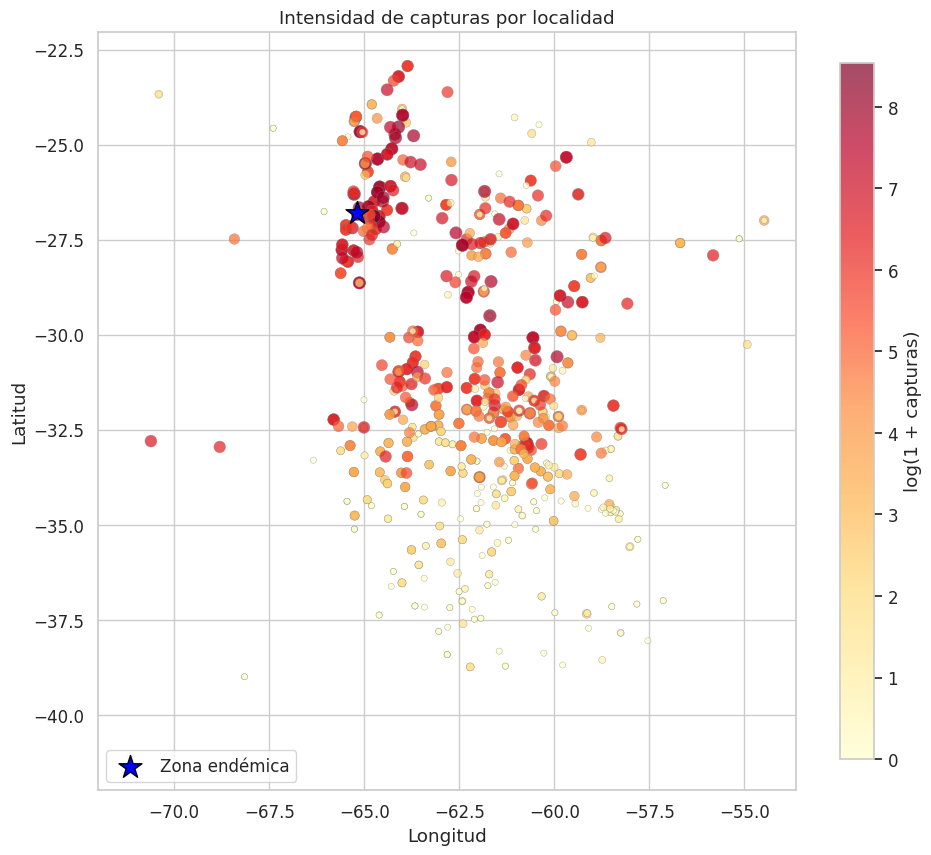

In [20]:
# 2.2 Mapa de intensidad de capturas
fig, ax = plt.subplots(figsize=(10, 12))

capturas_log = np.log1p(df_geo["max_capturas"].fillna(0))
sizes = 20 + capturas_log * 8

sc = ax.scatter(
    df_geo["lon"], df_geo["lat"],
    c=capturas_log, cmap="YlOrRd", s=sizes,
    alpha=0.7, edgecolors="gray", linewidth=0.3,
)
ax.scatter(-65.2, -26.8, c="blue", marker="*", s=300, zorder=5,
           edgecolors="black", linewidth=1, label="Zona endémica")

cbar = plt.colorbar(sc, ax=ax, shrink=0.6, label="log(1 + capturas)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Intensidad de capturas por localidad")
ax.legend(loc="lower left")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2571021/219199809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y="dist_zona_endemica_km",
/tmp/ipykernel_2571021/219199809.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([TARGET_LABELS[0], TARGET_LABELS[1]])


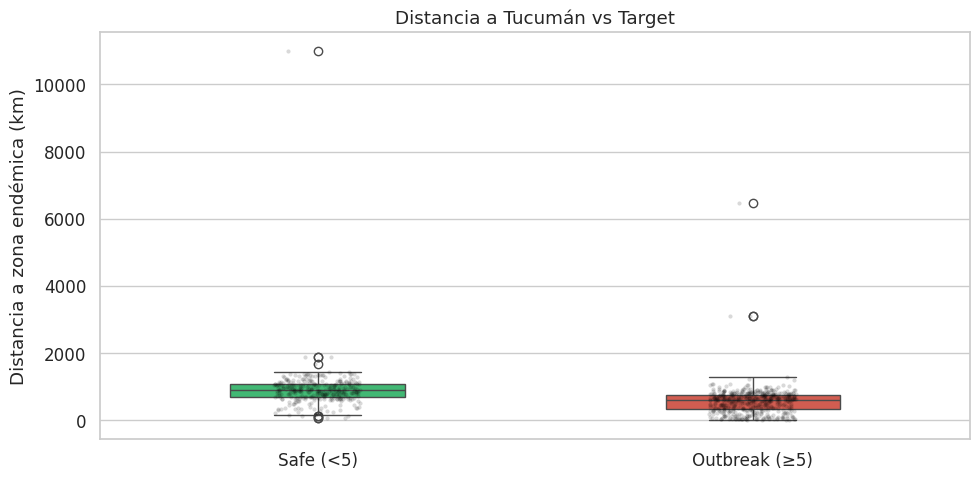

In [21]:
# 2.3 Distancia a zona endémica vs target
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="target", y="dist_zona_endemica_km",
            palette=[TARGET_COLORS[0], TARGET_COLORS[1]], ax=ax, width=0.4)
sns.stripplot(data=df, x="target", y="dist_zona_endemica_km",
              color="black", alpha=0.15, size=3, ax=ax)
ax.set_xticklabels([TARGET_LABELS[0], TARGET_LABELS[1]])
ax.set_xlabel("")
ax.set_ylabel("Distancia a zona endémica (km)")
ax.set_title("Distancia a Tucumán vs Target")
plt.tight_layout()
plt.show()

## 3. Features climáticas

/tmp/ipykernel_2571021/2282958689.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col,
/tmp/ipykernel_2571021/2282958689.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Safe", "Outbreak"])
/tmp/ipykernel_2571021/2282958689.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col,
/tmp/ipykernel_2571021/2282958689.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Safe", "Outbreak"])
/tmp/ipykernel_2571021/2282958689.py:13: Fut

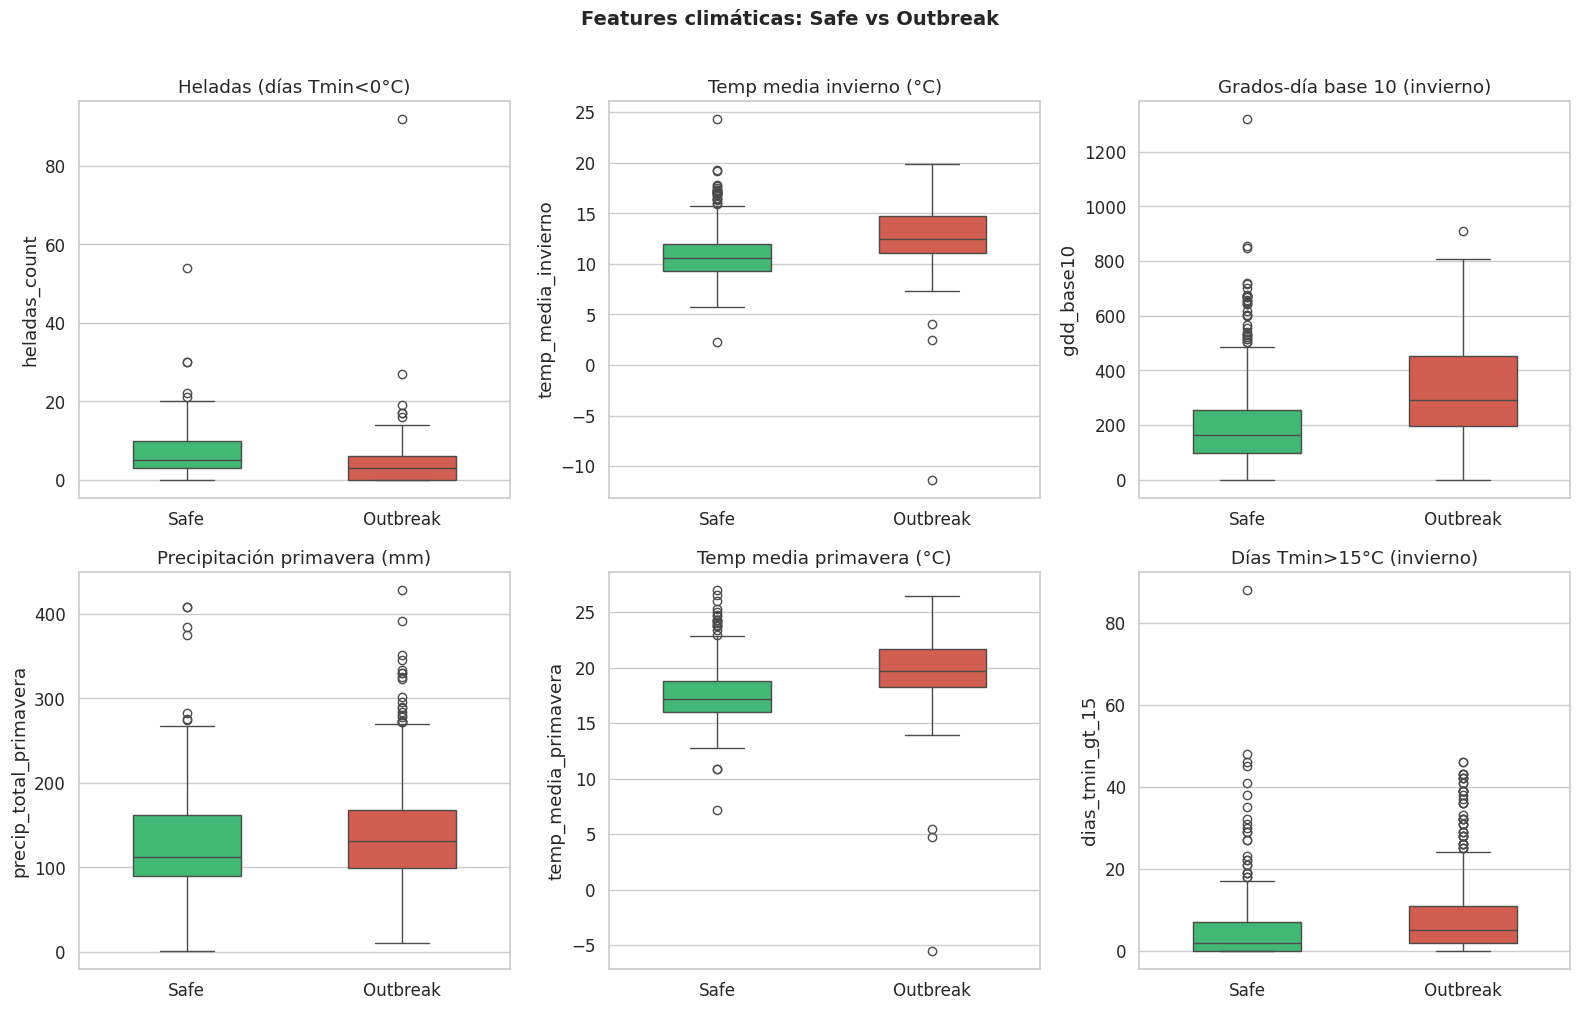

In [22]:
# 3.1 Comparación de features clave por target (grid de boxplots)
key_features = [
    ("heladas_count", "Heladas (días Tmin<0°C)"),
    ("temp_media_invierno", "Temp media invierno (°C)"),
    ("gdd_base10", "Grados-día base 10 (invierno)"),
    ("precip_total_primavera", "Precipitación primavera (mm)"),
    ("temp_media_primavera", "Temp media primavera (°C)"),
    ("dias_tmin_gt_15", "Días Tmin>15°C (invierno)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (col, title) in zip(axes.flat, key_features):
    sns.boxplot(data=df, x="target", y=col,
                palette=[TARGET_COLORS[0], TARGET_COLORS[1]], ax=ax, width=0.5)
    ax.set_xticklabels(["Safe", "Outbreak"])
    ax.set_xlabel("")
    ax.set_title(title)

plt.suptitle("Features climáticas: Safe vs Outbreak", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

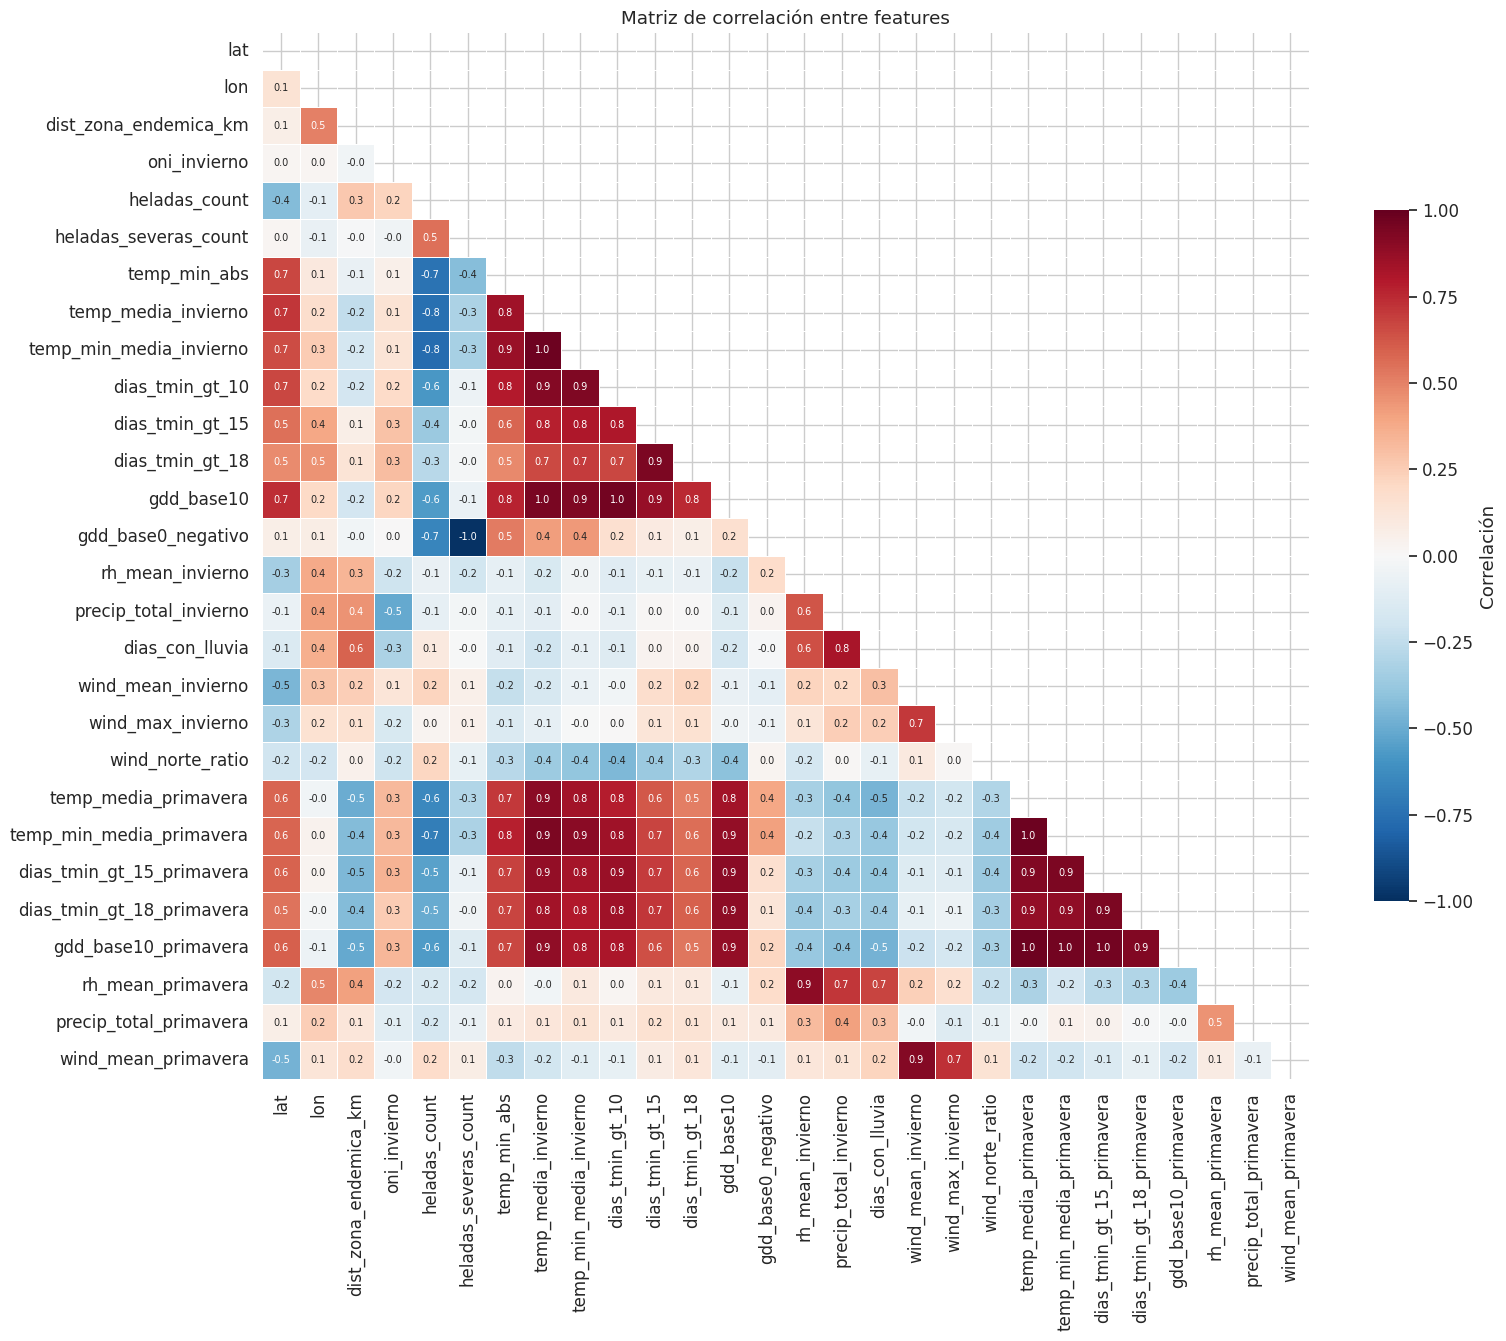

In [23]:
# 3.2 Matriz de correlación
fig, ax = plt.subplots(figsize=(16, 14))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Correlación"},
            annot=True, fmt=".1f", annot_kws={"size": 7})
ax.set_title("Matriz de correlación entre features")
plt.tight_layout()
plt.show()

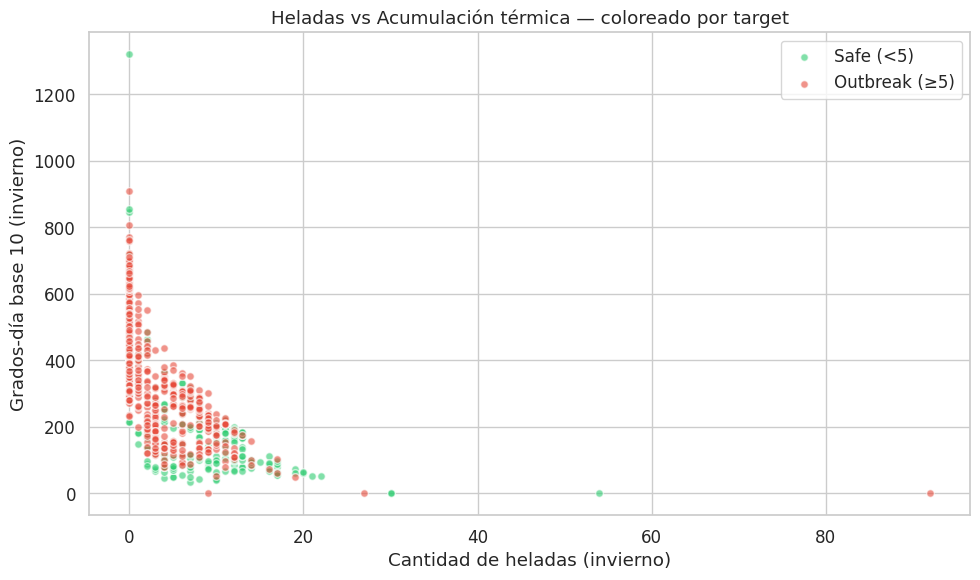

In [24]:
# 3.3 Heladas vs Grados-día acumulados
fig, ax = plt.subplots(figsize=(10, 6))
for t in [0, 1]:
    mask = df["target"] == t
    ax.scatter(df.loc[mask, "heladas_count"], df.loc[mask, "gdd_base10"],
               c=TARGET_COLORS[t], label=TARGET_LABELS[t], alpha=0.6, s=30, edgecolors="white")
ax.set_xlabel("Cantidad de heladas (invierno)")
ax.set_ylabel("Grados-día base 10 (invierno)")
ax.set_title("Heladas vs Acumulación térmica — coloreado por target")
ax.legend()
plt.tight_layout()
plt.show()

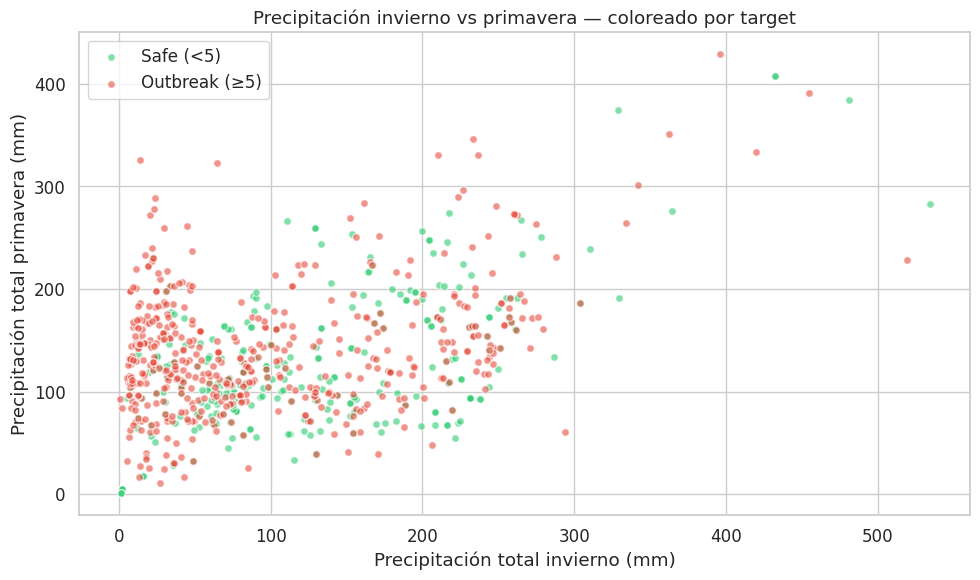

In [25]:
# 3.4 Precipitación invierno vs primavera
fig, ax = plt.subplots(figsize=(10, 6))
for t in [0, 1]:
    mask = df["target"] == t
    ax.scatter(df.loc[mask, "precip_total_invierno"], df.loc[mask, "precip_total_primavera"],
               c=TARGET_COLORS[t], label=TARGET_LABELS[t], alpha=0.6, s=30, edgecolors="white")
ax.set_xlabel("Precipitación total invierno (mm)")
ax.set_ylabel("Precipitación total primavera (mm)")
ax.set_title("Precipitación invierno vs primavera — coloreado por target")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Resumen por región

In [26]:
# 4.1 Tabla resumen por región
summary = (
    df.groupby("region")
    .agg(
        n_localidades=("localidad", "count"),
        pct_outbreak=("target", "mean"),
        media_capturas=("max_capturas", "median"),
        media_heladas=("heladas_count", "mean"),
        media_gdd=("gdd_base10", "mean"),
        media_temp_inv=("temp_media_invierno", "mean"),
        media_dist_endemica=("dist_zona_endemica_km", "mean"),
    )
    .reindex([r for r in REGION_ORDER if r in df["region"].values])
)
summary["pct_outbreak"] = (summary["pct_outbreak"] * 100).round(1).astype(str) + "%"
summary = summary.rename(columns={
    "n_localidades": "Localidades",
    "pct_outbreak": "% Outbreak",
    "media_capturas": "Capturas (mediana)",
    "media_heladas": "Heladas (media)",
    "media_gdd": "GDD base10 (media)",
    "media_temp_inv": "Temp inv. (media °C)",
    "media_dist_endemica": "Dist. endémica (km)",
})
summary.round(1)

,Localidades,% Outbreak,Capturas (mediana),Heladas (media),GDD base10 (media),Temp inv. (media °C),Dist. endémica (km)
region,,,,,,,
NOA,117,97.4%,675.0,1.8,398.3,13.8,176.8
NEA,145,77.2%,125.0,1.2,510.6,15.1,551.9
CENTRO NORTE,133,81.2%,118.0,5.3,255.4,11.9,610.5
LITORAL,62,82.3%,80.0,3.1,364.1,13.3,772.8
CENTRO SUR,275,42.5%,2.0,8.2,152.2,10.2,973.8
URUGUAY,44,9.1%,0.0,7.6,230.5,11.1,922.2
